In [1]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import numpy as np
import os
import json

gg-5000-aggressive-4
gg-8000-aggressive-4
gg-6000-aggressive-3
gg-10000-aggressive-2
gg-2000-aggressive-1
gg-500-aggressive-1
gg-1000-aggressive-4
gg-4000-aggressive-3
gg-10000-aggressive-3
gg-100-aggressive-1
gg-500-aggressive-3
gg-6000-aggressive-1
gg-500-aggressive-4
gg-10-aggressive-2
gg-2000-aggressive-2
gg-10-aggressive-1
gg-6000-aggressive-2
gg-500-aggressive-2
gg-8000-aggressive-2
gg-8000-aggressive-3
gg-8000-aggressive-1
gg-5000-aggressive-2
gg-4000-aggressive-4
gg-100-aggressive-5
gg-10000-aggressive-1
gg-2000-aggressive-3
gg-100-aggressive-3
gg-1000-aggressive-3
gg-10000-aggressive-4
gg-2000-aggressive-4
gg-5000-aggressive-1
gg-1000-aggressive-2
gg-100-aggressive-2
gg-4000-aggressive-1
gg-1000-aggressive-1
gg-5000-aggressive-3
gg-10-aggressive-3
gg-6000-aggressive-4
gg-100-aggressive-4
gg-10-aggressive-4
gg-4000-aggressive-2
gg-8000-aggressive-4
gg-6000-aggressive-3
gg-10000-aggressive-2
gg-2000-aggressive-1
gg-6000-aggressive-0
gg-8000-aggressive-0
gg-500-aggressive-1
gg-10

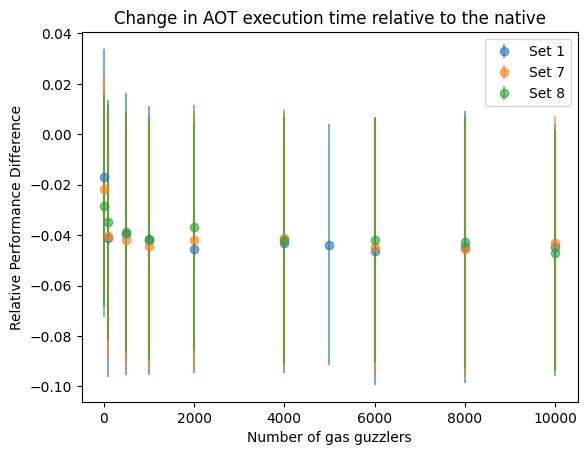

In [2]:
def parse_data(path, skip_err=True):
	df = pd.read_csv(path).drop_duplicates()
	if skip_err:
		df = df[df["err"].isna()]
	df = df.drop(columns=['err'])
	df = df.groupby(['id', 'run_type']).mean().reset_index() # For any duplicated block_num, we take the mean of the values 
	df_wide = df.pivot(index='id', columns='run_type', values='exe_time').dropna(axis=0).reset_index()

	diff_ratios = (df_wide['aot'] - df_wide['native']) / df_wide['native']
	diff_ratios = remove_outliers_zscore(diff_ratios)
	mean = np.mean(diff_ratios)
	stddev = np.std(diff_ratios)

	return mean, stddev

def remove_outliers_zscore(series, z_threshold=3):
	z_scores = np.abs(stats.zscore(series))
	return series[z_scores < z_threshold]


sets = [
	("Set 1", "../.data/measurements-public/gg_exe_compare/"),
	# ("Set 2", "../.data/measurements-public/gg_exe_compare_2/"),
	# ("Set 5", "../.data/measurements-public/gg_exe_compare_5/"),
	# ("Set 6", "../.data/measurements-public/gg_exe_compare_6/"),
	("Set 7", "../.data/measurements-public/gg_exe_compare_7/"),
	("Set 8", "../.data/measurements-public/gg_exe_compare_8/"),
]
skip_err = False

df = pd.DataFrame()
for set_id, dir in sets:
	runs = [f for f in os.listdir(dir) if os.path.isdir(os.path.join(dir, f))]
	for run in runs:
		print(run)
		if run in ("gg-1000-aggressive-3"):
			continue

		mean, stddev = parse_data(os.path.join(dir, run, "data.csv"), skip_err)
		gg_config = json.load(open(os.path.join(dir, run, "config.json")))
		gg_size = gg_config["bytecode_selection"]["GasGuzzlers"]["size_limit"]
		comp_opt_lvl = gg_config["args"].get("comp_opt_level", gg_config.get("compile_opt_lvl"))

		_df = pd.DataFrame({
			"size_limit": [gg_size], 
			"mean": [mean], 
			"stddev": [stddev],
			"comp_opt_lvl": [comp_opt_lvl],
			"set_id": [set_id]
		})
		df = pd.concat([df, _df])

df_sorted = df.sort_values(by="size_limit")

for key in df_sorted["set_id"].unique():
	df_filtered = df_sorted[df_sorted["set_id"] == key]
	grouped = df_filtered.groupby("size_limit").agg({"mean": "mean", "stddev": "mean"}).reset_index()
	plt.errorbar(grouped["size_limit"], grouped["mean"], yerr=grouped["stddev"], fmt='o', label=key, alpha=0.6)
	# plt.scatter(df_filtered["size_limit"], df_filtered["mean"], label=key, alpha=0.6)

# plt.xscale('log')
plt.xlabel('Number of gas guzzlers')
plt.ylabel('Relative Performance Difference')
plt.title('Change in AOT execution time relative to the native')
plt.legend()
plt.style.use('ggplot')
plt.show()

In [1]:

def analyser_from_path(data_path):
	df = pd.read_csv(data_path).drop_duplicates()
	return Analyser(df)

class Analyser:
    
	def __init__(self, df, skip_err=True):
		self.df = self._parse_data(df, skip_err)

	def perform_t_test(self, alpha=0.01):
		sample = self.diff_ratios()
		
		t_stat, p_value = stats.ttest_1samp(sample, 0)

		print(f"Mean: {np.mean(sample):.4f}")
		print(f"T-statistic: {t_stat:.4f}")
		print(f"P-value: {p_value:.4f}")
		print(f"StdDev: {np.std(sample):.4f}")

		print("\nVerdict:")
		if p_value < alpha:
			print(f"Reject the null hypothesis H0 at significance level {alpha}.")
			if t_stat < 0:
				print("H1: The mean latency of the new method is significantly less than the old one.")
			else:
				print("H2: The mean latency of the new method is significantly greater than the old one.")
		else:
			print(f"Fail to reject the null hypothesis H0 at significance level {alpha}.")
			print("H0: The mean latency of the new method is the same as the old one.")

	def plot_hist(self):
		data = self.diff_ratios()
		plt.hist(data, bins=120, alpha=0.5, label=r"$\frac{t_{aot}-t_{native}}{t_{native}}$")
		plt.xlabel('Change in execution time relative to the native')
		plt.ylabel('Frequency')
		plt.title('Histogram of change in execution time')
		plt.legend()
		plt.show()
	
	def diff_ratios(self):
		return (self.df['aot'] - self.df['native']) / self.df['native']
	
	@staticmethod
	def _parse_data(df, skip_err=True):
		if skip_err:
			df = df[df["err"].isna()]
		df = df.drop(columns=['err'])
		df = df.groupby(['id', 'run_type']).mean().reset_index() # For any duplicated block_num, we take the mean of the values 
		df_wide = df.pivot(index='id', columns='run_type', values='exe_time').dropna(axis=0).reset_index()
		print(f"Found {len(df_wide)} pairs with min-block-num: {df_wide['id'].min()} and max-block-num: {df_wide['id'].max()}")
		return df_wide

dir = "../.data/measurements-public/gg_exe_compare_3/"
runs = [f for f in os.listdir(dir) if os.path.isdir(os.path.join(dir, f))]
for run in runs:
	print(f"Analyzing {run}")
	path = os.path.join(dir, run, "data.csv")
	ana = analyser_from_path(path)
	ana.perform_t_test()
	ana.plot_hist()
	print("\n\n")


NameError: name 'os' is not defined